In [ ]:
pip install --quiet diffrax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.4/140.4 KB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 KB 6.0 MB/s eta 0:00:00


In [ ]:
import diffrax as dx
import jax
import jax.numpy as jnp
from jax.experimental import sparse
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
from jax.config import config
config.update("jax_enable_x64", True)

## Evolution equations

We have the PDE

$\partial_t a = \partial^2_x a +  (a-\alpha)(a-\beta)(1 - a) + b$

$\partial_t b = \rho\partial^2_x b + \varepsilon (b - \mu a b) + \sigma$

with initial conditions

$a(x, 0) = 0$

$b(x, 0) = b_0(x)$

and $\sigma(x, t)$ a forcing function that models bacterial dosage.

## Semi-discretized evolution equations

Let's discretize the spatial coordinate over the bounded domain $x\in[-\frac{L}{2}, \frac{L}{2}]$, giving us an $n$-dimensional ODE system for $\mathbf{a}(t) \in \mathbb{R}_+^n$ and $\mathbf{b}(t) \in \mathbb{R}_+^n$, with uniform grid spacing $\delta x = \frac{L}{n}$:

$$
\begin{align}
\mathbf{\dot a} &= \Delta^{(2)} \ \mathbf{a} + (\mathbf{a}-\alpha\mathbf{1})\odot(\mathbf{a}-\beta \mathbf{1})\odot(\mathbf{1} - \mathbf{a}) + \mathbf{b}\\
\mathbf{\dot b} &= \rho \ \Delta^{(2)} \ \mathbf{b} + \varepsilon (\mathbf{b} - \mu \ \mathbf{a} \odot \mathbf{b}) + \boldsymbol{\sigma}
\end{align}
$$

with initial conditions

$$
\begin{align}
\mathbf{a}(0) &= \mathbf{0}\\
\mathbf{b}(0) &= \mathbf{b}_0
\end{align}
$$

where $\Delta^{(2)}$ denotes the second-order discrete difference operator

$$
\Delta^{(2)}_{ij} =
\frac{1}{\delta x^2}
\begin{bmatrix}
2 & -5 & 4      & -1     &        &     \\[1mm]
1 & -2 & 1      &        &        &    \\[1mm]
& 1  & -2     & 1      &        &    \\[1mm]
&    & \ddots & \ddots & \ddots &    \\[1mm]
&        &        & 1      & -2 & 1 \\[1mm]
&        &     -1  & 4      & -5 & 2
\end{bmatrix}
$$

Fix discretization

In [ ]:
L = 100.0
n = 1000
δx = L / n

x = jnp.linspace(0, L, n)

Define finite difference operator

In [ ]:
Δ = jnp.diag(-2 * jnp.ones(n, dtype=int)) + jnp.diag(jnp.ones(n - 1, dtype=int), k=-1) + jnp.diag(jnp.ones(n - 1, dtype=int), k=1)
Δ = Δ.at[0, :4].set([2, -5, 4, -1])
Δ = Δ.at[-1, -4:].set([-1, 4, -5, 2])

Δ


Array([[ 2, -5,  4, ...,  0,  0,  0],
       [ 1, -2,  1, ...,  0,  0,  0],
       [ 0,  1, -2, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., -2,  1,  0],
       [ 0,  0,  0, ...,  1, -2,  1],
       [ 0,  0,  0, ...,  4, -5,  2]], dtype=int64)

Scale $\Delta$ according to the grid spacing $\delta x$ and convert to a sparse array.

In [ ]:
Δ = sparse.BCOO.fromdense(Δ / δx)

Define an aggregate vector $\mathbf{y}(t)\in\mathbb{R}^{2n}$ by spatially interleaving the elements $\mathbf{a}$ and $\mathbf{b}$

$$
\mathbf{y}(t) = \left[a_1(t), b_1(t), \dots, a_n(t), b_n(t)\right]^{\,\intercal}
$$

then we have an ODE system in standard form

$$
\mathbf{\dot y} = f(t, \mathbf{y}), \quad \mathbf{y}(0) = \mathbf{y}_0
$$

In [ ]:
@jax.jit
def interleave(a, b):
  y = jnp.empty(len(a) + len(b))
  y = y.at[::2].set(a)
  y = y.at[1::2].set(b)
  return y

@jax.jit
def unravel(y):
  return y[::2], y[1::2]

In [ ]:
@jax.jit
def σ(t, dosages, dosage_idxs, dosage_times, bw):
  result = jnp.zeros(n)
  result = result.at[dosage_idxs].set(jnp.squeeze(dosages * jax.scipy.stats.norm.pdf(jnp.atleast_1d(t)[:, None], loc=dosage_times, scale=bw)).sum())
  return result

In [ ]:
@jax.jit
def f(t, y, args):
  α, β, ρ, ε, μ, dosages, dosage_idxs, dosage_times, bw = args

  a, b = unravel(y)

  a_dot = Δ @ a + (a - α) * (a - β) * (1 - a) + b
  b_dot = ρ * Δ @ b + ε * (b - μ * a * b) + σ(t, dosages, dosage_idxs, dosage_times, bw)

  return interleave(a_dot, b_dot)

Fix a time grid

In [ ]:
t = jnp.linspace(0, 600, 400)

Fix parameters

In [ ]:
α = 0.001
β = 0.2
ρ = 3.0
ε = 0.01
μ = 100.0

dosages = 4e-1 * jnp.array([4, 5])
dosage_idxs = (jnp.array([L / 2, L / 2]) // δx).astype(int)
dosage_times = jnp.array([20.0, 200.0])
bw = t[1] - t[0]

Fix initial condition

In [ ]:
a0 = α * jnp.ones(n)
# a0 = a0.at[n // 2].set(1e-2)
b0 = jnp.zeros(n)
# b0 = b0.at[n // 2].set(1e-3)
# b0 = b0.at[n // 2 - 20].set(1e-2)

y0 = interleave(a0, b0)


Solve!

In [ ]:
args = α, β, ρ, ε, μ, dosages, dosage_idxs, dosage_times, bw

In [ ]:
ode_term = dx.ODETerm(f)
rtol = 1e-5
atol = 1e-5
max_steps = 100000
dt0 = 1e-3
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)

solution = dx.diffeqsolve(ode_term, solver, args=args,
                                t0=t[0], t1=t[-1], dt0=dt0,
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )
a, b = unravel(solution.ys.T)

In [ ]:
a.shape, b.shape

((1000, 400), (1000, 400))

In [ ]:
plt.style.use('dark_background')

In [ ]:
a_max = a.max()
b_max = b.max()

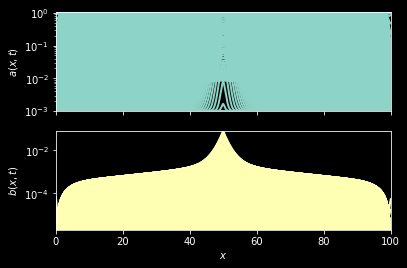

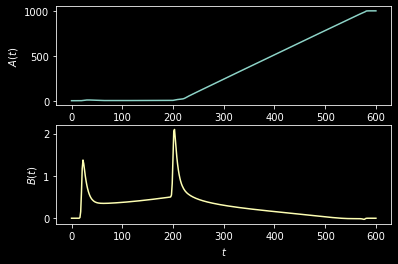

In [ ]:
ax = plt.subplot(211)
plt.plot(x, a, "C0", lw=2)
ax.set_ylabel(r"$a(x, t)$")
ax.tick_params(labelbottom=False)
ax.set_yscale("log")
ax.set_ylim(α, a_max)
ax = plt.subplot(212, sharex=ax)
plt.plot(x, b, "C1", lw=2)
ax.set_xlabel("$x$")
ax.set_xlim(0, L)
ax.set_ylabel(r"$b(x, t)$")
ax.set_yscale("log")
ax.set_ylim(1e-6 * dosages.max(), b_max)
plt.show()

ax = plt.subplot(211)
plt.plot(t, a.sum(0), "C0")
ax.set_ylabel(r"$A(t)$")
ax = plt.subplot(212, sharex=ax)
plt.plot(t, b.sum(0), "C1")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$B(t)$")
plt.show()

In [ ]:
a_mean = a.mean(0)
b_mean = b.mean(0)

a_mean_max = a_mean.max()
b_mean_max = b_mean.max()

In [ ]:
fps = 10

frame_freq = 5

fig, ax = plt.subplots(2, 2, sharex="col", figsize=(8, 3), width_ratios=(2, 1))

def update(frame):
    ax[0, 0].clear()
    ax[0, 0].plot(x, a[:, frame_freq * frame], "C0", lw=2)
    ax[0, 0].set_title(rf"$t = {t[frame]:.1f}$")
    ax[0, 0].set_ylabel(r"$a(x, t)$")
    ax[0, 0].set_ylim(α, 1.01 * a_max)
    ax[0, 0].set_yscale("log")
    ax[0, 0].tick_params(labelbottom=False)

    ax[1, 0].clear()
    ax[1, 0].plot(x, b[:, frame_freq * frame], "C1", lw=2)
    ax[1, 0].set_xlabel("$x$")
    ax[1, 0].set_ylabel(r"$b(x, t)$")
    ax[1, 0].set_xlim(0, L)
    ax[1, 0].set_ylim(1e-4 * dosages.max(), 1.01 * b_max)
    ax[1, 0].set_yscale("log")

    ax[0, 1].clear()
    ax[0, 1].set_title(rf"spatially averaged dynamics")
    ax[0, 1].plot(t[:frame_freq * frame], a_mean[:frame_freq * frame], "C0")
    ax[0, 1].set_xlim(t.min(), t.max())
    ax[0, 1].set_ylabel(r"$\langle a \rangle(t)$")
    ax[0, 1].set_ylim(α, 1.01 * a_mean_max)
    ax[0, 1].set_yscale("log")

    ax[1, 1].clear()
    ax[1, 1].plot(t[:frame_freq * frame], b_mean[:frame_freq * frame], "C1")
    ax[1, 1].set_xlim(t.min(), t.max())
    ax[1, 1].set_xlabel("$t$")
    ax[1, 1].set_ylim(1e-4 * dosages.max(), 1.01 * b_mean_max)
    ax[1, 1].set_yscale("log")
    ax[1, 1].set_ylabel(r"$\langle b \rangle(t)$")

    fig.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=len(t) // frame_freq, interval=1000/fps)
html_video = HTML(ani.to_jshtml())
plt.close()
html_video


In [ ]:
ani.save('animation2.mp4', fps=fps, dpi=200)